In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✅ Libraries imported successfully!\n")

# Load the Mayo Cirrhosis Dataset
data_path = Path("../data/raw/cirrhosis1.csv")
df = pd.read_csv(data_path)

print("=== Mayo Clinic Cirrhosis1 Dataset ===")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

print("First 5 rows preview:")
display(df.head())

print("\nTarget Variable (Stage) Distribution:")
print(df['Stage'].value_counts().sort_index())

print("\nMissing Values (%):")
missing = df.isnull().mean() * 100
print(missing[missing > 0].sort_values(ascending=False).round(2))

✅ Libraries imported successfully!

=== Mayo Clinic Cirrhosis1 Dataset ===
Shape: 418 rows × 20 columns

First 5 rows preview:


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,58.8,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,56.5,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,70.1,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,54.8,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,38.1,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0



Target Variable (Stage) Distribution:
Stage
1.0     21
2.0     92
3.0    155
4.0    144
Name: count, dtype: int64

Missing Values (%):
Tryglicerides    32.54
Cholesterol      32.06
Copper           25.84
Drug             25.36
Ascites          25.36
Hepatomegaly     25.36
Spiders          25.36
Alk_Phos         25.36
SGOT             25.36
Platelets         2.63
Stage             1.44
Prothrombin       0.48
dtype: float64


In [2]:
# # Convert Age from Days to Years
# df['Age_Years'] = (df['Age'] / 365).round(1)

# # Drop old Age column
# df.drop('Age', axis=1, inplace=True)

# # Check output
# print(df[['Age_Years']].head())


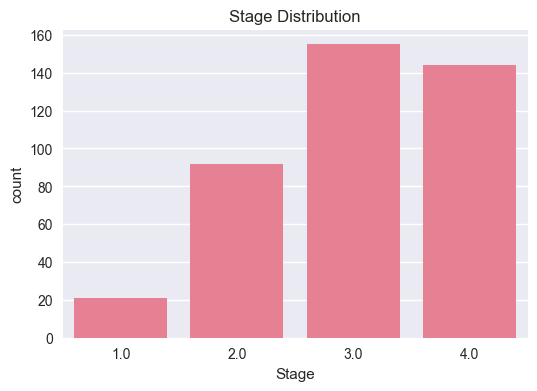

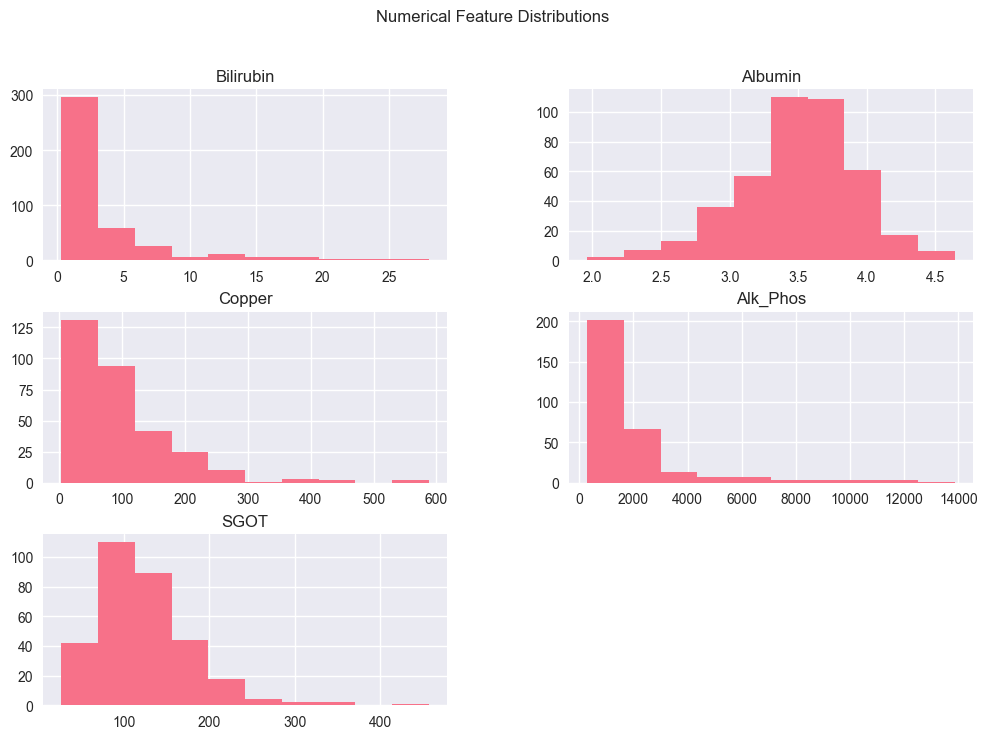

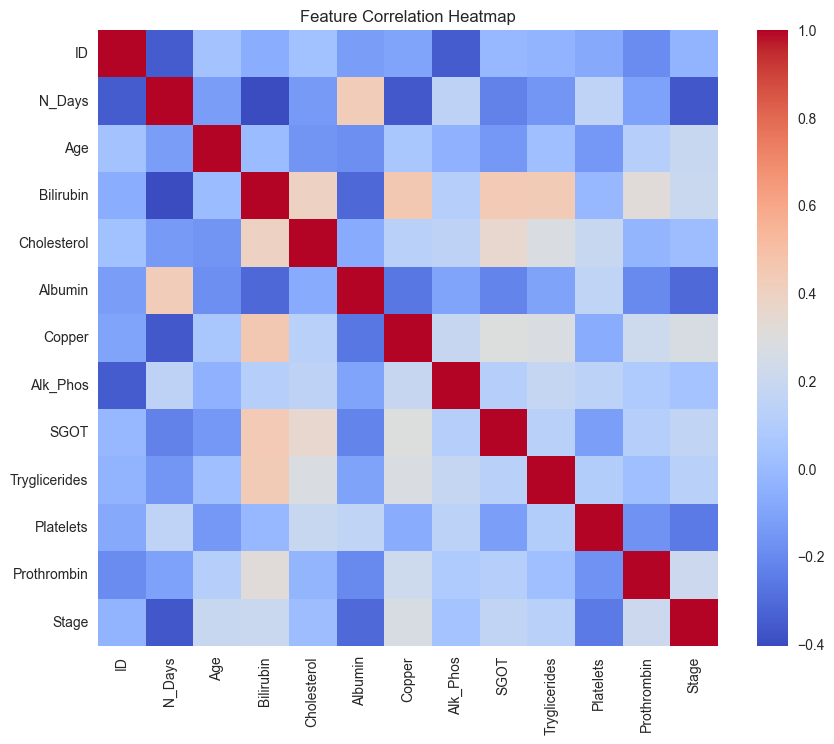

In [ ]:

# 1. Target Distribution Plot

plt.figure(figsize=(6,4))
sns.countplot(x='Stage', data=df)
plt.title("Stage Distribution")
plt.show()



# 2. Numerical Feature Distribution

num_cols = ['Bilirubin', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT']

df[num_cols].hist(figsize=(12,8))
plt.suptitle("Numerical Feature Distributions")
plt.show()



# 3. Correlation Heatmap

plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [4]:
# ===============================
# Data Cleaning & Preprocessing
# ===============================

df_clean = df.copy()

# Drop ID (not useful)
df_clean.drop(columns=['ID'], inplace=True)

# Handle missing values
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
    else:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Encode categorical variables
df_clean = pd.get_dummies(df_clean, drop_first=True)

print("After preprocessing:")
print(df_clean.shape)

After preprocessing:
(418, 21)


/var/folders/kz/rqlzffjn7kx3mbtn4stlt1240000gn/T/ipykernel_47362/3052921219.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/var/folders/kz/rqlzffjn7kx3mbtn4stlt1240000gn/T/ipykernel_47362/3052921219.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting

In [5]:
# Convert Stage into Binary Classes

# 0 = Low Risk (Stage 1 & 2)
# 1 = High Risk (Stage 3 & 4)

df_clean['Risk'] = df_clean['Stage'].apply(
    lambda x: 0 if x in [1, 2] else 1
)

# Check distribution
print(df_clean['Risk'].value_counts())

Risk
1    305
0    113
Name: count, dtype: int64


In [6]:
X = df_clean.drop('Risk', axis=1)
y = df_clean['Risk']

In [7]:
X = X.drop(columns=[
    'N_Days',
    'Status_CL',
    'Status_D',
    'Drug_Placebo'
])

In [8]:
print(X.columns)

Index(['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos',
       'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Sex_M',
       'Ascites_Y', 'Hepatomegaly_Y', 'Spiders_Y', 'Edema_S', 'Edema_Y'],
      dtype='object')


In [9]:
## Split Data
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_clean.drop([
    'Stage',
    'Risk',
    'N_Days',
    'Status_CL',
    'Status_D',
    'Drug_Placebo'
], axis=1)
y = df_clean['Risk']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (334, 16)
Test shape: (84, 16)


In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report

# # Train model
# model = LogisticRegression(max_iter=1000)
# model.fit(X_train, y_train)

# # Predictions
# y_pred = model.predict(X_test)

# # Evaluation
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:\n")
# print(classification_report(y_test, y_pred))

Accuracy: 0.7380952380952381

Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.30      0.39        23
           1       0.77      0.90      0.83        61

    accuracy                           0.74        84
   macro avg       0.66      0.60      0.61        84
weighted avg       0.71      0.74      0.71        84



/Users/harshchauhan/Desktop/liver-cirrhosis-prediction-advanced/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
#Use Class Weights
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6428571428571429

Classification Report:

              precision    recall  f1-score   support

           0       0.39      0.57      0.46        23
           1       0.80      0.67      0.73        61

    accuracy                           0.64        84
   macro avg       0.60      0.62      0.60        84
weighted avg       0.69      0.64      0.66        84



/Users/harshchauhan/Desktop/liver-cirrhosis-prediction-advanced/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
import sys
!{sys.executable} -m pip install imbalanced-learn


In [13]:
from imblearn.over_sampling import SMOTE

In [14]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_resampled.shape)


Before SMOTE: (334, 16)
After SMOTE: (488, 16)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression(max_iter=2000)
model.fit(X_resampled, y_resampled)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6428571428571429

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.48      0.42        23
           1       0.78      0.70      0.74        61

    accuracy                           0.64        84
   macro avg       0.58      0.59      0.58        84
weighted avg       0.67      0.64      0.65        84



/Users/harshchauhan/Desktop/liver-cirrhosis-prediction-advanced/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
# rf_model = RandomForestClassifier(
#     n_estimators=500,
#     max_depth=10,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     max_features='sqrt',
#     class_weight='balanced',
#     random_state=42
# )

rf_model.fit(X_resampled, y_resampled)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7023809523809523

Classification Report:

              precision    recall  f1-score   support

           0       0.44      0.35      0.39        23
           1       0.77      0.84      0.80        61

    accuracy                           0.70        84
   macro avg       0.61      0.59      0.60        84
weighted avg       0.68      0.70      0.69        84



In [17]:
!pip install xgboost


In [18]:
import sys
!{sys.executable} -m pip install xgboost

In [19]:
!pip3 install --upgrade pip

         Feature  Importance
8      Platelets    0.116488
3        Albumin    0.115210
0            Age    0.112858
1      Bilirubin    0.109386
9    Prothrombin    0.100766
7  Tryglicerides    0.099803
4         Copper    0.082447
6           SGOT    0.070070
5       Alk_Phos    0.069091
2    Cholesterol    0.058316


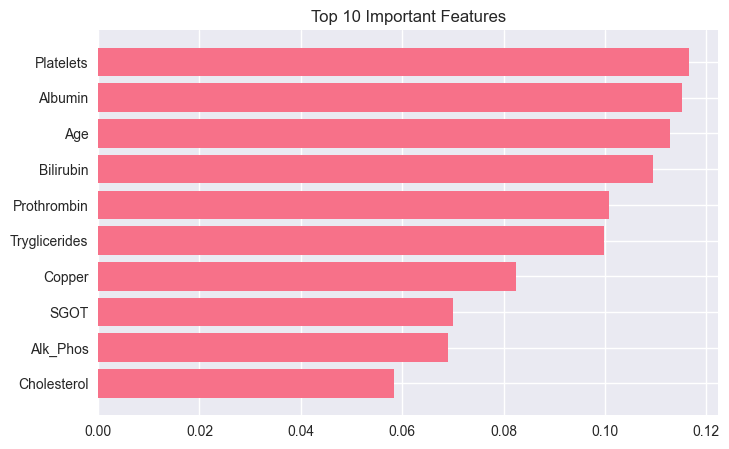

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_
features = X.columns

# Create DataFrame
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Show top features
print(feat_df.head(10))

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_df['Feature'][:10], feat_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

Top 10 Important Features:
         Feature  Importance
8      Platelets    0.116488
3        Albumin    0.115210
0            Age    0.112858
1      Bilirubin    0.109386
9    Prothrombin    0.100766
7  Tryglicerides    0.099803
4         Copper    0.082447
6           SGOT    0.070070
5       Alk_Phos    0.069091
2    Cholesterol    0.058316


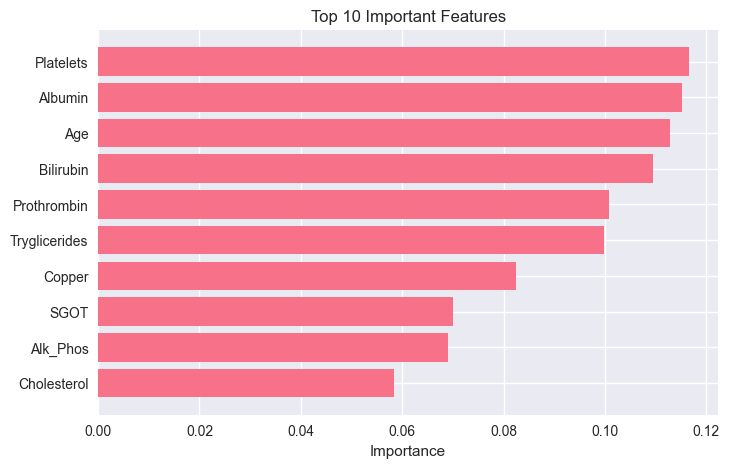

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
importances = rf_model.feature_importances_

# Feature names
features = X.columns

# Create DataFrame
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort by importance
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Print top 10 features
print("Top 10 Important Features:")
print(feat_df.head(10))


# Plot graph
plt.figure(figsize=(8,5))
plt.barh(feat_df['Feature'][:10], feat_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

In [22]:
!pip install shap

In [23]:
import sys
!{sys.executable} -m pip install shap

/Users/harshchauhan/Desktop/liver-cirrhosis-prediction-advanced/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


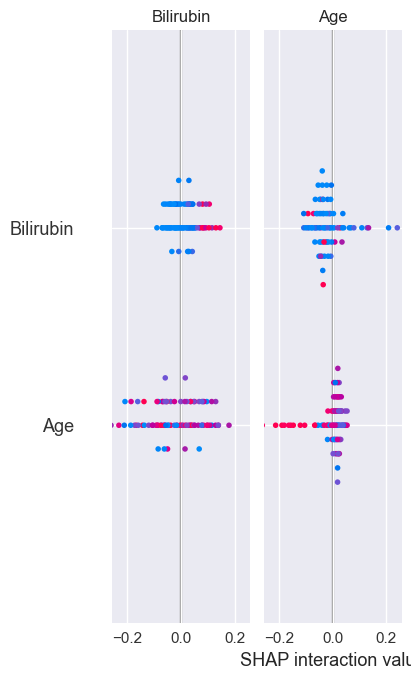

In [24]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Get SHAP values
shap_values = explainer.shap_values(X_test)

# Plot summary
shap.summary_plot(shap_values, X_test)

## TRAIN XGBOOST (apni sahuliyat ke liye)

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
xgb_model = XGBClassifier(

    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,

    eval_metric='logloss',
    random_state=42
)

# Train model
xgb_model.fit(X_resampled, y_resampled)

# Prediction
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.6666666666666666

Classification Report:

              precision    recall  f1-score   support

           0       0.39      0.39      0.39        23
           1       0.77      0.77      0.77        61

    accuracy                           0.67        84
   macro avg       0.58      0.58      0.58        84
weighted avg       0.67      0.67      0.67        84



## abhi mai ab tak ke best model RF ke liye confusion matrix

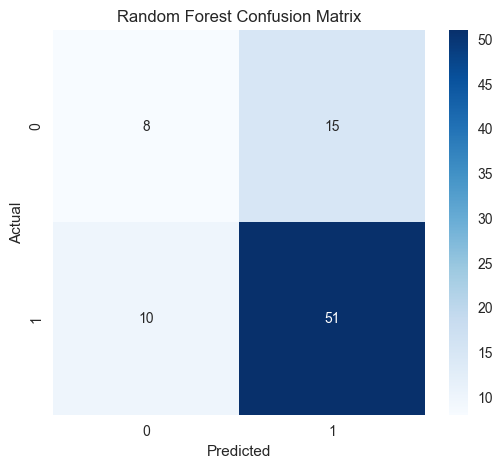

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC-AUC curve :- how well your model separates low-risk and high-risk patients

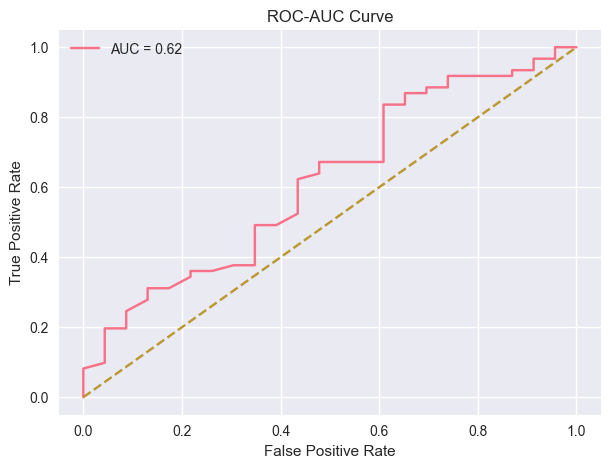

AUC Score: 0.6168923734853884


In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Prediction probabilities
y_prob = rf_model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve")

plt.legend()

plt.show()

print("AUC Score:", auc_score)

In [28]:
import joblib

# Save Random Forest model
joblib.dump(rf_model, 'liver_rf_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [29]:
print(X.columns)

Index(['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos',
       'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Sex_M',
       'Ascites_Y', 'Hepatomegaly_Y', 'Spiders_Y', 'Edema_S', 'Edema_Y'],
      dtype='object')
